In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path.cwd().resolve().parent
METADATA = BASE / "metadata"
PROCESSED = BASE / "data_processed"
RESULTS = BASE / "results"

RESULTS.mkdir(parents=True, exist_ok=True)

print("BASE:", BASE)
print("RESULTS:", RESULTS)

BASE: /Users/wukezhang416/govresponseai
RESULTS: /Users/wukezhang416/govresponseai/results


In [2]:
doc_index = pd.read_csv(METADATA / "doc_index.csv")

rows = []
with (PROCESSED / "all_chunks.jsonl").open("r", encoding="utf-8") as f:
    for line in f:
        rows.append(json.loads(line))

df_text = pd.DataFrame(rows)

print("doc_index shape:", doc_index.shape)
print("df_text shape:", df_text.shape)
print(df_text["country"].value_counts())
display(doc_index.head())
display(df_text.head())

doc_index shape: (18, 8)
df_text shape: (2963, 9)
country
US    2481
CN     482
Name: count, dtype: int64


,doc_id,country,title,issuing_body,date,url,format,notes
0,us_doc1,US,AI Risk Management Framework 1.0,NIST,2023-01-26,https://nvlpubs.nist.gov/nistpubs/ai/nist.ai.1...,pdf,core framework
1,us_doc2,US,Blueprint for an AI Bill of Rights,OSTP/White House,2022-10-04,https://marketingstorageragrs.blob.core.window...,pdf,principles doc
2,us_doc3,US,OMB M-24-10: AI Governance & Risk Mgmt,OMB,2024-03-28,https://www.whitehouse.gov/wp-content/uploads/...,pdf,agency AI use governance memo
3,us_doc4,US,OMB M-24-18: Responsible AI Acquisition,OMB,2024-09-24,https://www.whitehouse.gov/wp-content/uploads/...,pdf,AI procurement memo
4,us_doc5,US,NIST AI 600-1: GenAI Profile,NIST,2024-07-01,https://nvlpubs.nist.gov/nistpubs/ai/NIST.AI.6...,pdf,GenAI risk profile companion to AI RMF


,doc_id,chunk_id,country,title,issuing_body,date,url,format,text
0,us_doc1,us_doc1_0000,US,AI Risk Management Framework 1.0,NIST,2023-01-26,https://nvlpubs.nist.gov/nistpubs/ai/nist.ai.1...,pdf,NIST AI 100-1\nArtificial Intelligence Risk Ma...
1,us_doc1,us_doc1_0001,US,AI Risk Management Framework 1.0,NIST,2023-01-26,https://nvlpubs.nist.gov/nistpubs/ai/nist.ai.1...,pdf,"Certain commercial entities, equipment, or mat..."
2,us_doc1,us_doc1_0002,US,AI Risk Management Framework 1.0,NIST,2023-01-26,https://nvlpubs.nist.gov/nistpubs/ai/nist.ai.1...,pdf,UpdateScheduleandVersions\nTheArtificialIntell...
3,us_doc1,us_doc1_0003,US,AI Risk Management Framework 1.0,NIST,2023-01-26,https://nvlpubs.nist.gov/nistpubs/ai/nist.ai.1...,pdf,change only with major revisions. Minor revisi...
4,us_doc1,us_doc1_0004,US,AI Risk Management Framework 1.0,NIST,2023-01-26,https://nvlpubs.nist.gov/nistpubs/ai/nist.ai.1...,pdf,Part1: FoundationalInformation 4\n1 FramingRis...


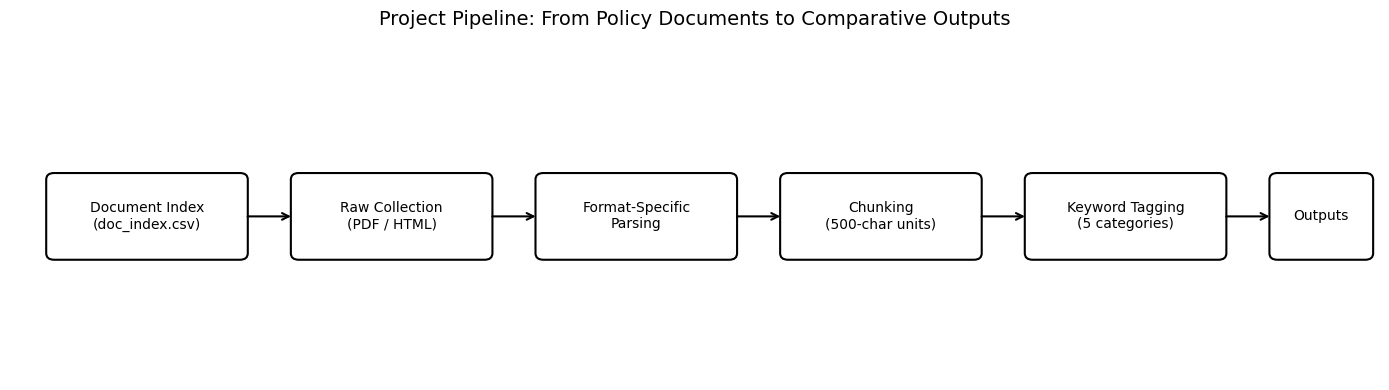

Saved: /Users/wukezhang416/govresponseai/results/fig_method_pipeline.png


In [24]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 4))
ax.set_xlim(0, 14)
ax.set_ylim(0, 4)
ax.axis("off")

boxes = [
    (0.4, 1.5, 2.0, 1.0, "Document Index\n(doc_index.csv)"),
    (2.9, 1.5, 2.0, 1.0, "Raw Collection\n(PDF / HTML)"),
    (5.4, 1.5, 2.0, 1.0, "Format-Specific\nParsing"),
    (7.9, 1.5, 2.0, 1.0, "Chunking\n(500-char units)"),
    (10.4, 1.5, 2.0, 1.0, "Keyword Tagging\n(5 categories)"),
    (12.9, 1.5, 1.0, 1.0, "Outputs")
]

for x, y, w, h, label in boxes:
    rect = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        linewidth=1.5, fill=False
    )
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha="center", va="center", fontsize=10)

for i in range(len(boxes) - 1):
    x1 = boxes[i][0] + boxes[i][2]
    y1 = boxes[i][1] + boxes[i][3] / 2
    x2 = boxes[i+1][0]
    y2 = boxes[i+1][1] + boxes[i+1][3] / 2
    arrow = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="->", mutation_scale=12, linewidth=1.5)
    ax.add_patch(arrow)

ax.set_title("Project Pipeline: From Policy Documents to Comparative Outputs", fontsize=14, pad=20)

plt.tight_layout()
plt.savefig(RESULTS / "fig_method_pipeline.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", RESULTS / "fig_method_pipeline.png")

In [3]:
chunk_counts = (
    df_text.groupby(["doc_id", "country", "title", "issuing_body", "date", "format"])
    .size()
    .reset_index(name="n_chunks")
    .sort_values(["country", "n_chunks"], ascending=[True, False])
)

corpus_overview = (
    doc_index.merge(
        chunk_counts[["doc_id", "n_chunks"]],
        on="doc_id",
        how="left"
    )
)

corpus_overview["n_chunks"] = corpus_overview["n_chunks"].fillna(0).astype(int)

display(corpus_overview)
corpus_overview.to_csv(RESULTS / "table_corpus_overview.csv", index=False)
print("Saved:", RESULTS / "table_corpus_overview.csv")

,doc_id,country,title,issuing_body,date,url,format,notes,n_chunks
0,us_doc1,US,AI Risk Management Framework 1.0,NIST,2023-01-26,https://nvlpubs.nist.gov/nistpubs/ai/nist.ai.1...,pdf,core framework,218
1,us_doc2,US,Blueprint for an AI Bill of Rights,OSTP/White House,2022-10-04,https://marketingstorageragrs.blob.core.window...,pdf,principles doc,489
2,us_doc3,US,OMB M-24-10: AI Governance & Risk Mgmt,OMB,2024-03-28,https://www.whitehouse.gov/wp-content/uploads/...,pdf,agency AI use governance memo,221
3,us_doc4,US,OMB M-24-18: Responsible AI Acquisition,OMB,2024-09-24,https://www.whitehouse.gov/wp-content/uploads/...,pdf,AI procurement memo,243
4,us_doc5,US,NIST AI 600-1: GenAI Profile,NIST,2024-07-01,https://nvlpubs.nist.gov/nistpubs/ai/NIST.AI.6...,pdf,GenAI risk profile companion to AI RMF,349
5,us_doc6,US,NIST AI RMF Playbook,NIST,2023-03-30,https://airc.nist.gov/docs/AI_RMF_Playbook.pdf,pdf,implementation playbook,728
6,us_doc7,US,NIST SP 800-218 SSDF,NIST,2022-02-03,https://nvlpubs.nist.gov/nistpubs/specialpubli...,pdf,governance/assurance framework baseline,233
7,cn_algo_2022,CN,互联网信息服务算法推荐管理规定,CAC+MIIT+MPS+SAMR,2021-12-31,https://www.cac.gov.cn/2022-01/04/c_1642894606...,html,algorithm recommendation regulation,11
8,cn_genai_2023,CN,生成式人工智能服务管理暂行办法,CAC,2023-07-13,https://www.cac.gov.cn/2023-07/13/c_1690898327...,html,interim measures for genAI services,9
9,cn_deepsynthesis_2022,CN,互联网信息服务深度合成管理规定,CAC+MIIT+MPS,2022-12-11,https://www.cac.gov.cn/2022-12/11/c_1672221949...,html,deep synthesis regulation,9


Saved: /Users/wukezhang416/govresponseai/results/table_corpus_overview.csv


In [4]:
country_corpus_summary = (
    corpus_overview.groupby("country")
    .agg(
        n_documents=("doc_id", "count"),
        total_chunks=("n_chunks", "sum")
    )
    .reset_index()
)

display(country_corpus_summary)
country_corpus_summary.to_csv(RESULTS / "table_country_corpus_summary.csv", index=False)
print("Saved:", RESULTS / "table_country_corpus_summary.csv")

,country,n_documents,total_chunks
0,CN,11,482
1,US,7,2481


Saved: /Users/wukezhang416/govresponseai/results/table_country_corpus_summary.csv


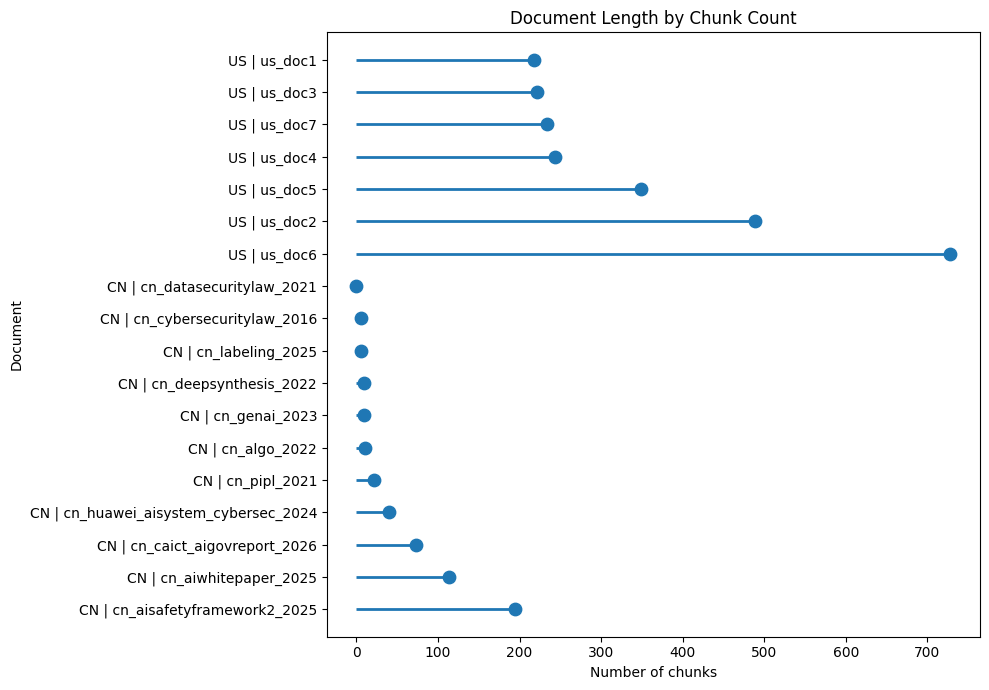

Saved: /Users/wukezhang416/govresponseai/results/fig_doc_chunk_lollipop.png


In [25]:
plot_df = corpus_overview[["doc_id", "country", "n_chunks"]].copy()
plot_df = plot_df.sort_values(["country", "n_chunks"], ascending=[True, False]).reset_index(drop=True)
plot_df["label"] = plot_df["country"] + " | " + plot_df["doc_id"]

fig, ax = plt.subplots(figsize=(10, 7))

y_pos = range(len(plot_df))
ax.hlines(y=y_pos, xmin=0, xmax=plot_df["n_chunks"], linewidth=2)
ax.scatter(plot_df["n_chunks"], y_pos, s=80)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(plot_df["label"])
ax.set_xlabel("Number of chunks")
ax.set_ylabel("Document")
ax.set_title("Document Length by Chunk Count")

plt.tight_layout()
plt.savefig(RESULTS / "fig_doc_chunk_lollipop.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", RESULTS / "fig_doc_chunk_lollipop.png")

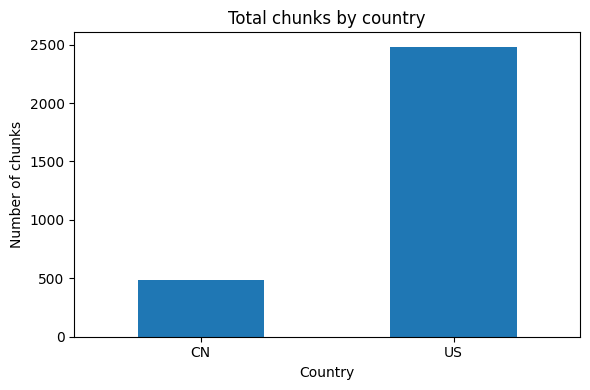

Saved: /Users/wukezhang416/govresponseai/results/fig_chunks_by_country.png


In [5]:
plot_df = country_corpus_summary.set_index("country")["total_chunks"]

ax = plot_df.plot(kind="bar", figsize=(6, 4))
ax.set_title("Total chunks by country")
ax.set_ylabel("Number of chunks")
ax.set_xlabel("Country")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(RESULTS / "fig_chunks_by_country.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", RESULTS / "fig_chunks_by_country.png")

In [6]:
KEYWORDS = {
    "TRANSPARENCY": [
        "transparen", "explain", "interpretab", "disclos", "notice", "documentation",
        "透明", "解释", "披露", "告知", "说明", "公开"
    ],
    "OVERSIGHT_AUDIT": [
        "audit", "oversight", "governance", "monitor", "evaluation", "assess", "review",
        "监督", "审计", "治理", "监测", "评估", "审查", "检查"
    ],
    "ACCOUNTABILITY_LIABILITY": [
        "accountab", "responsib", "liabil", "enforcement", "penalt", "compliance",
        "责任", "追责", "处罚", "罚款", "合规", "问责"
    ],
    "PUBLIC_PARTICIPATION": [
        "public", "stakeholder", "consult", "engage", "participat", "comment",
        "公众", "社会监督", "征求意见", "参与", "意见反馈", "评论", "投诉举报"
    ],
    "APPEALS_REMEDY": [
        "appeal", "complaint", "redress", "remedy", "grievance", "recourse",
        "申诉", "投诉", "救济", "纠错", "异议", "复议", "举报"
    ],
}

In [7]:
keyword_rows = []
for category, words in KEYWORDS.items():
    for word in words:
        keyword_rows.append({"category": category, "keyword": word})

keyword_table = pd.DataFrame(keyword_rows)

display(keyword_table.head(20))
keyword_table.to_csv(RESULTS / "table_keyword_dictionary.csv", index=False)
print("Saved:", RESULTS / "table_keyword_dictionary.csv")

,category,keyword
0,TRANSPARENCY,transparen
1,TRANSPARENCY,explain
2,TRANSPARENCY,interpretab
3,TRANSPARENCY,disclos
4,TRANSPARENCY,notice
5,TRANSPARENCY,documentation
6,TRANSPARENCY,透明
7,TRANSPARENCY,解释
8,TRANSPARENCY,披露
9,TRANSPARENCY,告知


Saved: /Users/wukezhang416/govresponseai/results/table_keyword_dictionary.csv


In [8]:
def tag_chunk(text):
    t = str(text).lower()
    return {
        category: int(any(k.lower() in t for k in words))
        for category, words in KEYWORDS.items()
    }

tag_rows = []
for _, rec in df_text.iterrows():
    tags = tag_chunk(rec["text"])
    tag_rows.append({
        "doc_id": rec["doc_id"],
        "country": rec["country"],
        "chunk_id": rec["chunk_id"],
        **tags
    })

df_tags = pd.DataFrame(tag_rows)

print(df_tags.shape)
print(df_tags["country"].value_counts())
display(df_tags.head())

(2963, 8)
country
US    2481
CN     482
Name: count, dtype: int64


,doc_id,country,chunk_id,TRANSPARENCY,OVERSIGHT_AUDIT,ACCOUNTABILITY_LIABILITY,PUBLIC_PARTICIPATION,APPEALS_REMEDY
0,us_doc1,US,us_doc1_0000,0,0,0,1,0
1,us_doc1,US,us_doc1_0001,0,0,0,1,0
2,us_doc1,US,us_doc1_0002,0,1,0,0,0
3,us_doc1,US,us_doc1_0003,0,1,0,1,0
4,us_doc1,US,us_doc1_0004,1,0,1,0,0


In [9]:
cats = list(KEYWORDS.keys())

country_summary = (
    df_tags.groupby("country")[cats]
    .mean()
    .reset_index()
)

display(country_summary)
country_summary.to_csv(RESULTS / "table_country_summary.csv", index=False)
print("Saved:", RESULTS / "table_country_summary.csv")

,country,TRANSPARENCY,OVERSIGHT_AUDIT,ACCOUNTABILITY_LIABILITY,PUBLIC_PARTICIPATION,APPEALS_REMEDY
0,CN,0.201245,0.699170,0.255187,0.145228,0.041494
1,US,0.211608,0.348247,0.203144,0.218460,0.016526


Saved: /Users/wukezhang416/govresponseai/results/table_country_summary.csv


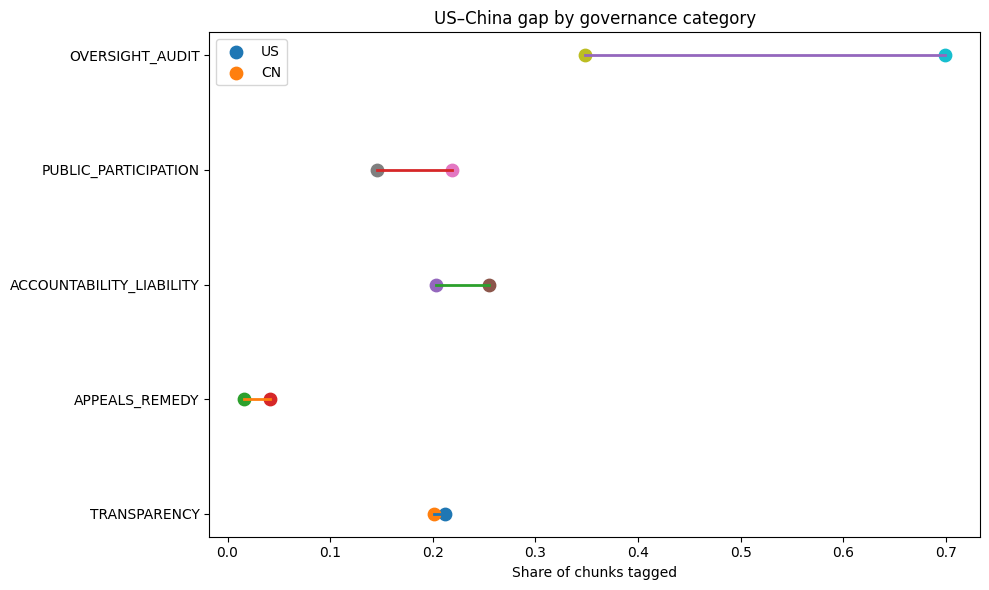

Saved: /Users/wukezhang416/govresponseai/results/fig_country_dumbbell.png


In [10]:
plot_df = country_summary.set_index("country")[cats].T.reset_index()
plot_df.columns = ["category", "CN", "US"]
plot_df["gap"] = (plot_df["CN"] - plot_df["US"]).abs()
plot_df = plot_df.sort_values("gap", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

for i, row in enumerate(plot_df.itertuples(index=False)):
    ax.plot([row.US, row.CN], [i, i], linewidth=2)
    ax.scatter(row.US, i, s=80, label="US" if i == 0 else "")
    ax.scatter(row.CN, i, s=80, label="CN" if i == 0 else "")

ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df["category"])
ax.set_xlabel("Share of chunks tagged")
ax.set_title("US–China gap by governance category")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "fig_country_dumbbell.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", RESULTS / "fig_country_dumbbell.png")

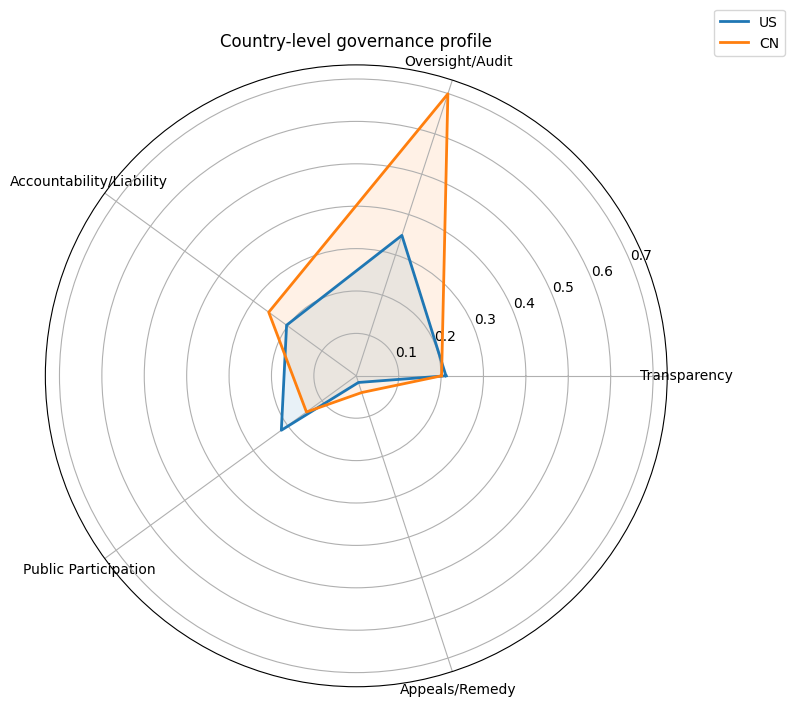

Saved: /Users/wukezhang416/govresponseai/results/fig_country_radar.png


In [19]:
import numpy as np

pretty_labels = [
    "Transparency",
    "Oversight/Audit",
    "Accountability/Liability",
    "Public Participation",
    "Appeals/Remedy"
]

radar_df = country_summary.set_index("country")[cats]

angles = np.linspace(0, 2 * np.pi, len(cats), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for country in ["US", "CN"]:
    values = radar_df.loc[country, cats].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=country)
    ax.fill(angles, values, alpha=0.10)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(pretty_labels)
ax.set_title("Country-level governance profile")
ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))

plt.tight_layout()
plt.savefig(RESULTS / "fig_country_radar.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", RESULTS / "fig_country_radar.png")

In [11]:
doc_summary = (
    df_tags.groupby(["country", "doc_id"])[cats]
    .mean()
    .reset_index()
)

doc_summary = doc_summary.merge(
    corpus_overview[["doc_id", "title", "issuing_body", "date", "n_chunks"]],
    on="doc_id",
    how="left"
)

display(doc_summary)
doc_summary.to_csv(RESULTS / "table_doc_summary.csv", index=False)
print("Saved:", RESULTS / "table_doc_summary.csv")

,country,doc_id,TRANSPARENCY,OVERSIGHT_AUDIT,ACCOUNTABILITY_LIABILITY,PUBLIC_PARTICIPATION,APPEALS_REMEDY,title,issuing_body,date,n_chunks
0,CN,cn_aisafetyframework2_2025,0.159794,0.644330,0.144330,0.159794,0.025773,人工智能安全治理框架2.0,TC260+国家计算机网络应急技术处理协调中心,2025-09-15,194
1,CN,cn_aiwhitepaper_2025,0.168142,0.805310,0.203540,0.070796,0.000000,人工智能安全治理白皮书（2025）,中国联通+华为+百度+360等,2025-07-01,113
2,CN,cn_algo_2022,0.454545,0.909091,0.454545,0.363636,0.272727,互联网信息服务算法推荐管理规定,CAC+MIIT+MPS+SAMR,2021-12-31,11
3,CN,cn_caict_aigovreport_2026,0.232877,0.904110,0.424658,0.150685,0.000000,人工智能安全治理研究报告（2025年）——推进人工智能安全治理产业实践框架,中国信息通信研究院,2026-01-09,73
4,CN,cn_cybersecuritylaw_2016,0.166667,0.666667,0.500000,0.333333,0.333333,中华人民共和国网络安全法,全国人大常委会,2016-11-07,6
5,CN,cn_deepsynthesis_2022,0.222222,0.555556,0.666667,0.444444,0.222222,互联网信息服务深度合成管理规定,CAC+MIIT+MPS,2022-12-11,9
6,CN,cn_genai_2023,0.333333,0.555556,0.444444,0.444444,0.333333,生成式人工智能服务管理暂行办法,CAC,2023-07-13,9
7,CN,cn_huawei_aisystem_cybersec_2024,0.100000,0.475000,0.300000,0.075000,0.000000,AI系统的网络安全治理实践,华为技术有限公司,2024-09-01,40
8,CN,cn_labeling_2025,0.166667,0.166667,0.333333,0.166667,0.166667,人工智能生成合成内容标识办法,CAC+MIIT+MPS+NRTA,2025-03-14,6
9,CN,cn_pipl_2021,0.666667,0.523810,0.428571,0.095238,0.190476,中华人民共和国个人信息保护法,全国人大常委会,2021-08-20,21


Saved: /Users/wukezhang416/govresponseai/results/table_doc_summary.csv


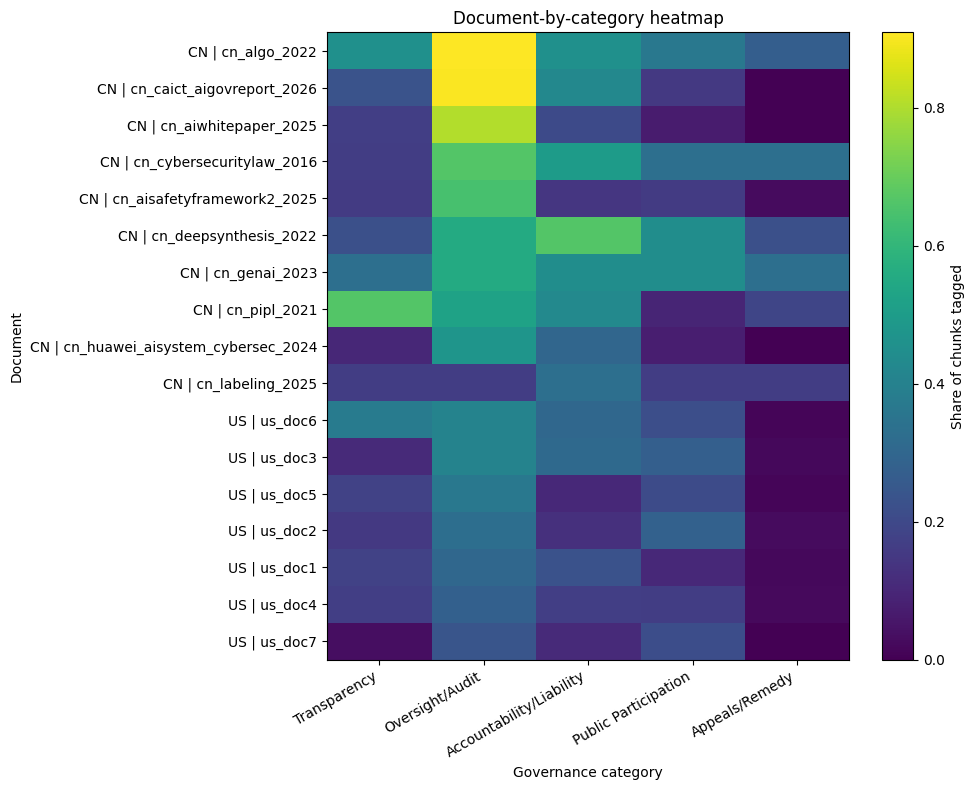

Saved: /Users/wukezhang416/govresponseai/results/fig_doc_category_heatmap.png


In [20]:
heatmap_df = doc_summary[["country", "doc_id", "title"] + cats].copy()

heatmap_df["doc_label"] = heatmap_df["country"] + " | " + heatmap_df["doc_id"]

heatmap_df = heatmap_df.sort_values(
    ["country", "OVERSIGHT_AUDIT"],
    ascending=[True, False]
)

heatmap_matrix = heatmap_df.set_index("doc_label")[cats]

pretty_cols = [
    "Transparency",
    "Oversight/Audit",
    "Accountability/Liability",
    "Public Participation",
    "Appeals/Remedy"
]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(heatmap_matrix.values, aspect="auto")

ax.set_xticks(range(len(cats)))
ax.set_xticklabels(pretty_cols, rotation=30, ha="right")

ax.set_yticks(range(len(heatmap_matrix.index)))
ax.set_yticklabels(heatmap_matrix.index)

ax.set_title("Document-by-category heatmap")
ax.set_xlabel("Governance category")
ax.set_ylabel("Document")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Share of chunks tagged")

plt.tight_layout()
plt.savefig(RESULTS / "fig_doc_category_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", RESULTS / "fig_doc_category_heatmap.png")

In [21]:
top_docs = (
    doc_summary[["country", "doc_id", "title", "n_chunks"] + cats]
    .sort_values(["country", "OVERSIGHT_AUDIT"], ascending=[True, False])
)

display(top_docs)
top_docs.to_csv(RESULTS / "table_top_documents_by_category.csv", index=False)
print("Saved:", RESULTS / "table_top_documents_by_category.csv")

,country,doc_id,title,n_chunks,TRANSPARENCY,OVERSIGHT_AUDIT,ACCOUNTABILITY_LIABILITY,PUBLIC_PARTICIPATION,APPEALS_REMEDY
2,CN,cn_algo_2022,互联网信息服务算法推荐管理规定,11,0.454545,0.909091,0.454545,0.363636,0.272727
3,CN,cn_caict_aigovreport_2026,人工智能安全治理研究报告（2025年）——推进人工智能安全治理产业实践框架,73,0.232877,0.904110,0.424658,0.150685,0.000000
1,CN,cn_aiwhitepaper_2025,人工智能安全治理白皮书（2025）,113,0.168142,0.805310,0.203540,0.070796,0.000000
4,CN,cn_cybersecuritylaw_2016,中华人民共和国网络安全法,6,0.166667,0.666667,0.500000,0.333333,0.333333
0,CN,cn_aisafetyframework2_2025,人工智能安全治理框架2.0,194,0.159794,0.644330,0.144330,0.159794,0.025773
5,CN,cn_deepsynthesis_2022,互联网信息服务深度合成管理规定,9,0.222222,0.555556,0.666667,0.444444,0.222222
6,CN,cn_genai_2023,生成式人工智能服务管理暂行办法,9,0.333333,0.555556,0.444444,0.444444,0.333333
9,CN,cn_pipl_2021,中华人民共和国个人信息保护法,21,0.666667,0.523810,0.428571,0.095238,0.190476
7,CN,cn_huawei_aisystem_cybersec_2024,AI系统的网络安全治理实践,40,0.100000,0.475000,0.300000,0.075000,0.000000
8,CN,cn_labeling_2025,人工智能生成合成内容标识办法,6,0.166667,0.166667,0.333333,0.166667,0.166667


Saved: /Users/wukezhang416/govresponseai/results/table_top_documents_by_category.csv


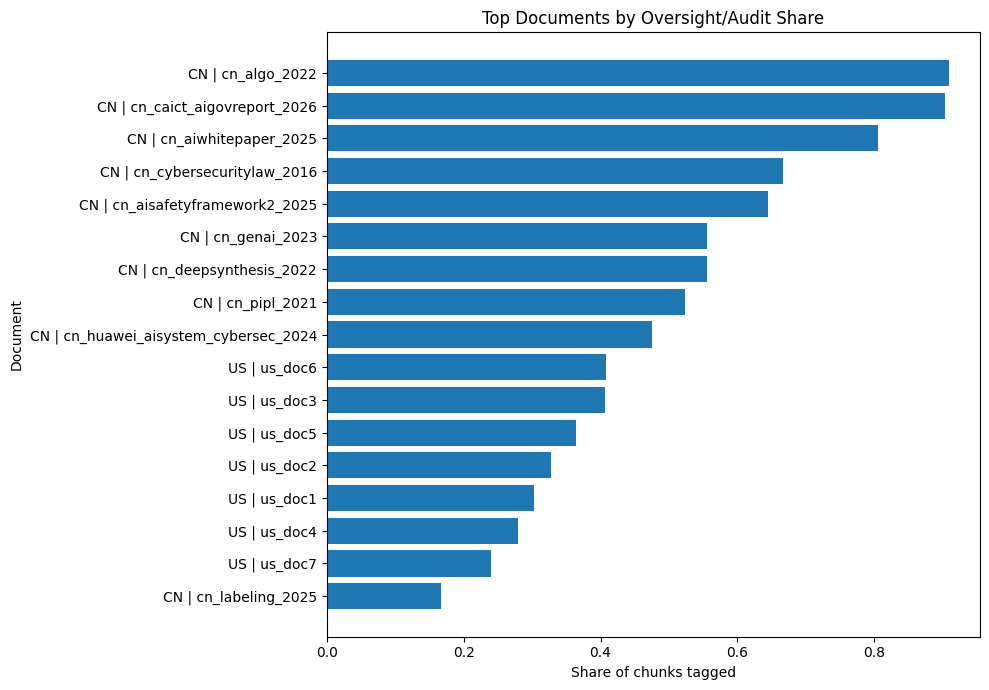

Saved: /Users/wukezhang416/govresponseai/results/fig_top_docs_oversight.png


In [26]:
metric = "OVERSIGHT_AUDIT"

plot_df = doc_summary[["country", "doc_id", metric]].copy()
plot_df["label"] = plot_df["country"] + " | " + plot_df["doc_id"]
plot_df = plot_df.sort_values([metric], ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_df["label"], plot_df[metric])

ax.set_xlabel("Share of chunks tagged")
ax.set_ylabel("Document")
ax.set_title("Top Documents by Oversight/Audit Share")

plt.tight_layout()
plt.savefig(RESULTS / "fig_top_docs_oversight.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", RESULTS / "fig_top_docs_oversight.png")

In [14]:
df_merge = df_tags.merge(
    df_text[["chunk_id", "doc_id", "country", "title", "text"]],
    on=["chunk_id", "doc_id", "country"],
    how="left"
)

snippet_rows = []
for category in cats:
    for country in ["US", "CN"]:
        subset = df_merge[(df_merge["country"] == country) & (df_merge[category] == 1)].head(2)
        for _, r in subset.iterrows():
            snippet_rows.append({
                "category": category,
                "country": country,
                "doc_id": r["doc_id"],
                "title": r["title"],
                "chunk_id": r["chunk_id"],
                "text_snippet": r["text"][:300].replace("\n", " ") + "..."
            })

examples_df = pd.DataFrame(snippet_rows)

display(examples_df)
examples_df.to_csv(RESULTS / "table_representative_snippets.csv", index=False)
print("Saved:", RESULTS / "table_representative_snippets.csv")

,category,country,doc_id,title,chunk_id,text_snippet
0,TRANSPARENCY,US,us_doc1,AI Risk Management Framework 1.0,us_doc1_0004,Part1: FoundationalInformation 4 1 FramingRisk...
1,TRANSPARENCY,US,us_doc1,AI Risk Management Framework 1.0,us_doc1_0008,"tion, and validation tasks. Note that AI actor..."
2,TRANSPARENCY,CN,cn_algo_2022,互联网信息服务算法推荐管理规定,cn_algo_2022_0002,提供算法推荐服务，应当遵守法律法规，尊重社会公德和伦理，遵守商业道德和职业道德，遵循公正公平...
3,TRANSPARENCY,CN,cn_algo_2022,互联网信息服务算法推荐管理规定,cn_algo_2022_0004,鼓励算法推荐服务提供者综合运用内容去重、打散干预等策略，并优化检索、排序、选择、推送、展示等...
4,OVERSIGHT_AUDIT,US,us_doc1,AI Risk Management Framework 1.0,us_doc1_0002,UpdateScheduleandVersions TheArtificialIntelli...
5,OVERSIGHT_AUDIT,US,us_doc1,AI Risk Management Framework 1.0,us_doc1_0003,change only with major revisions. Minor revisi...
6,OVERSIGHT_AUDIT,CN,cn_algo_2022,互联网信息服务算法推荐管理规定,cn_algo_2022_0000,互联网信息服务算法推荐管理规定_中央网络安全和信息化委员会办公室 设为首页 加入收藏 手机版...
7,OVERSIGHT_AUDIT,CN,cn_algo_2022,互联网信息服务算法推荐管理规定,cn_algo_2022_0001,为了规范互联网信息服务算法推荐活动，弘扬社会主义核心价值观，维护国家安全和社会公共利益，保护...
8,ACCOUNTABILITY_LIABILITY,US,us_doc1,AI Risk Management Framework 1.0,us_doc1_0004,Part1: FoundationalInformation 4 1 FramingRisk...
9,ACCOUNTABILITY_LIABILITY,US,us_doc1,AI Risk Management Framework 1.0,us_doc1_0006,Table3 Categoriesandsubcategoriesforthe MEASUR...


Saved: /Users/wukezhang416/govresponseai/results/table_representative_snippets.csv


In [30]:
failed_path = PROCESSED / "failed_docs.json"

if failed_path.exists():
    with failed_path.open("r", encoding="utf-8") as f:
        failed_docs = json.load(f)
    failed_df = pd.DataFrame(failed_docs)
else:
    failed_df = pd.DataFrame(columns=["doc_id", "reason"])

display(failed_df)
failed_df.to_csv(RESULTS / "table_failed_docs.csv", index=False)
print("Saved:", RESULTS / "table_failed_docs.csv")

,doc_id,reason
0,cn_datasecuritylaw_2021,"HTTPSConnectionPool(host='www.npc.gov.cn', por..."


Saved: /Users/wukezhang416/govresponseai/results/table_failed_docs.csv


In [31]:
report_summary = {
    "n_us_documents": int((corpus_overview["country"] == "US").sum()),
    "n_cn_documents": int((corpus_overview["country"] == "CN").sum()),
    "n_us_chunks": int(country_corpus_summary.loc[country_corpus_summary["country"] == "US", "total_chunks"].iloc[0]),
    "n_cn_chunks": int(country_corpus_summary.loc[country_corpus_summary["country"] == "CN", "total_chunks"].iloc[0]),
    "n_failed_docs": int(len(failed_df))
}

report_summary_df = pd.DataFrame([report_summary])
display(report_summary_df)
report_summary_df.to_csv(RESULTS / "table_report_summary_numbers.csv", index=False)
print("Saved:", RESULTS / "table_report_summary_numbers.csv")

,n_us_documents,n_cn_documents,n_us_chunks,n_cn_chunks,n_failed_docs
0,7,11,2481,482,1


Saved: /Users/wukezhang416/govresponseai/results/table_report_summary_numbers.csv


In [33]:
artifacts = pd.DataFrame([
    {"type": "table", "name": "Corpus overview", "file": "table_corpus_overview.csv"},
    {"type": "table", "name": "Country corpus summary", "file": "table_country_corpus_summary.csv"},
    {"type": "table", "name": "Country keyword summary", "file": "table_country_summary.csv"},
    {"type": "table", "name": "Document keyword summary", "file": "table_doc_summary.csv"},
    {"type": "table", "name": "Representative snippets", "file": "table_representative_snippets.csv"},
    {"type": "table", "name": "Failed docs", "file": "table_failed_docs.csv"},
    {"type": "table", "name": "Keyword dictionary", "file": "table_keyword_dictionary.csv"},
    {"type": "figure", "name": "Method pipeline", "file": "fig_method_pipeline.png"},
    {"type": "figure", "name": "Document chunk lollipop", "file": "fig_doc_chunk_lollipop.png"},
    {"type": "figure", "name": "Chunks by country", "file": "fig_chunks_by_country.png"},
    {"type": "figure", "name": "Country dumbbell", "file": "fig_country_dumbbell.png"},
    {"type": "figure", "name": "Country radar", "file": "fig_country_radar.png"},
    {"type": "figure", "name": "Document category heatmap", "file": "fig_doc_category_heatmap.png"},
    {"type": "figure", "name": "Document ranking by oversight", "file": "fig_top_docs_oversight.png"},
])

display(artifacts)
artifacts.to_csv(RESULTS / "artifact_inventory.csv", index=False)
print("Saved:", RESULTS / "artifact_inventory.csv")

,type,name,file
0,table,Corpus overview,table_corpus_overview.csv
1,table,Country corpus summary,table_country_corpus_summary.csv
2,table,Country keyword summary,table_country_summary.csv
3,table,Document keyword summary,table_doc_summary.csv
4,table,Representative snippets,table_representative_snippets.csv
5,table,Failed docs,table_failed_docs.csv
6,table,Keyword dictionary,table_keyword_dictionary.csv
7,figure,Method pipeline,fig_method_pipeline.png
8,figure,Document chunk lollipop,fig_doc_chunk_lollipop.png
9,figure,Chunks by country,fig_chunks_by_country.png


Saved: /Users/wukezhang416/govresponseai/results/artifact_inventory.csv
